# Resume Screening & Hiring Prediction Analysis

This project analyzes candidate resume data to understand hiring patterns and predict whether a candidate will be hired.

Objectives:
- Explore candidate education and experience
- Identify key factors influencing hiring
- Analyze skill and resume characteristics
- Build a machine learning model to predict hiring decisions

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

plt.style.use("ggplot")

In [3]:
df = pd.read_csv("archive/resume_dataset_200k_enhanced.csv")

df.head()

,candidate_id,age,education_level,university_tier,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,hired,soft_skills_score,resume_length_words,company_type
0,1,27,Bachelors,Tier 2,8.16,2,7,2,2,0.33,0,0,21.0,1,5.62,409,MNC
1,2,24,Bachelors,Tier 3,6.35,3,2,2,2,4.99,0,0,11.0,1,9.66,237,Startup
2,3,33,Bachelors,Tier 3,7.78,0,2,4,2,0.93,0,0,15.0,1,8.12,435,Startup
3,4,31,Masters,Tier 3,6.92,2,1,4,1,0.37,0,0,11.5,1,7.19,340,MNC
4,5,28,Masters,Tier 2,8.24,3,0,1,2,0.33,0,0,5.0,0,4.09,371,Mid-size


In [4]:
print("Dataset Shape:", df.shape)

df.info()

df.describe()

Dataset Shape: (200000, 17)
<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   candidate_id           200000 non-null  int64  
 1   age                    200000 non-null  int64  
 2   education_level        200000 non-null  str    
 3   university_tier        200000 non-null  str    
 4   cgpa                   200000 non-null  float64
 5   internships            200000 non-null  int64  
 6   projects               200000 non-null  int64  
 7   programming_languages  200000 non-null  int64  
 8   certifications         200000 non-null  int64  
 9   experience_years       200000 non-null  float64
 10  hackathons             200000 non-null  int64  
 11  research_papers        200000 non-null  int64  
 12  skills_score           200000 non-null  float64
 13  hired                  200000 non-null  int64  
 14  soft_skills_score  

,candidate_id,age,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,hired,soft_skills_score,resume_length_words
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,27.511705,7.499323,1.503015,2.996240,3.004420,1.000985,1.499030,0.498005,0.201950,14.000803,0.706060,6.502866,449.206975
std,57735.171256,4.030684,0.800952,1.225373,1.731104,1.412229,1.002217,1.497477,0.706773,0.448806,4.766263,0.455566,2.019637,120.103065
min,1.000000,21.000000,4.150000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000,-79.000000
25%,50000.750000,24.000000,6.960000,1.000000,2.000000,2.000000,0.000000,0.430000,0.000000,0.000000,10.500000,0.000000,4.750000,368.000000
50%,100000.500000,28.000000,7.500000,1.000000,3.000000,3.000000,1.000000,1.040000,0.000000,0.000000,14.000000,1.000000,6.510000,449.000000
75%,150000.250000,31.000000,8.040000,2.000000,4.000000,4.000000,2.000000,2.080000,1.000000,0.000000,17.000000,1.000000,8.250000,530.000000
max,200000.000000,34.000000,11.230000,10.000000,14.000000,5.000000,8.000000,23.550000,6.000000,5.000000,38.500000,1.000000,10.000000,956.000000


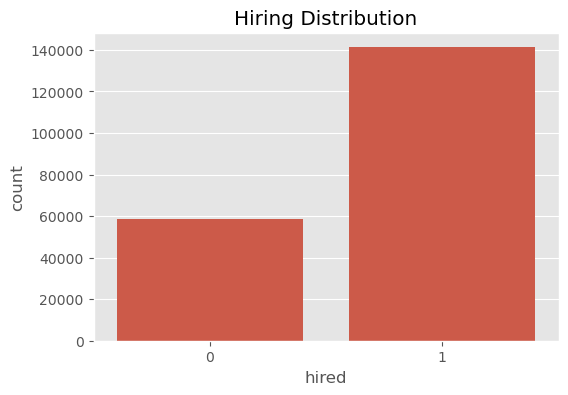

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="hired")

plt.title("Hiring Distribution")

plt.show()

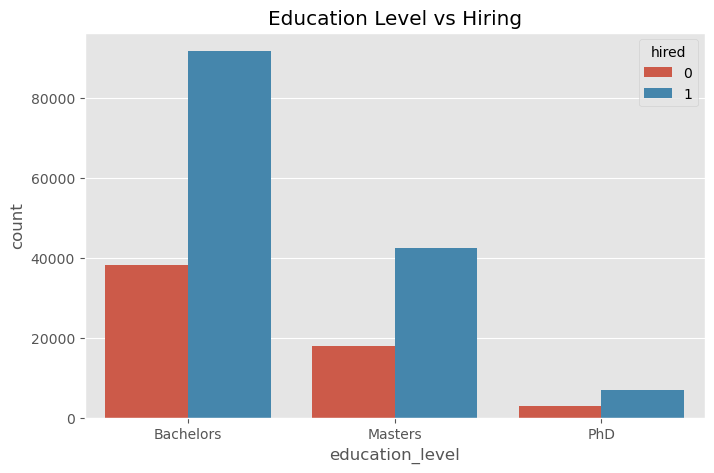

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="education_level",
    hue="hired"
)

plt.title("Education Level vs Hiring")

plt.show()

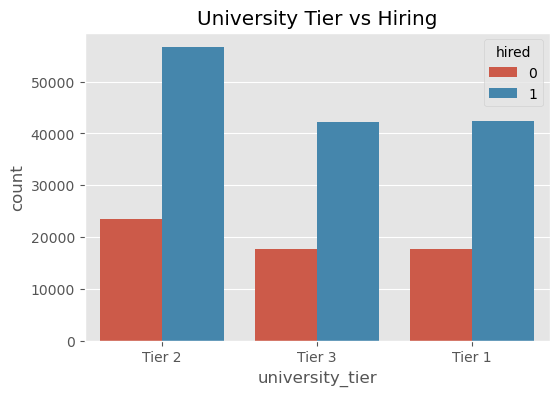

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="university_tier",
    hue="hired"
)

plt.title("University Tier vs Hiring")

plt.show()

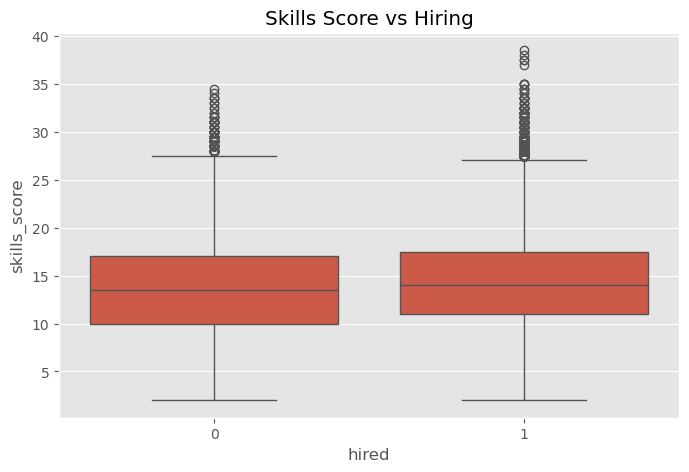

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="hired",
    y="skills_score"
)

plt.title("Skills Score vs Hiring")

plt.show()

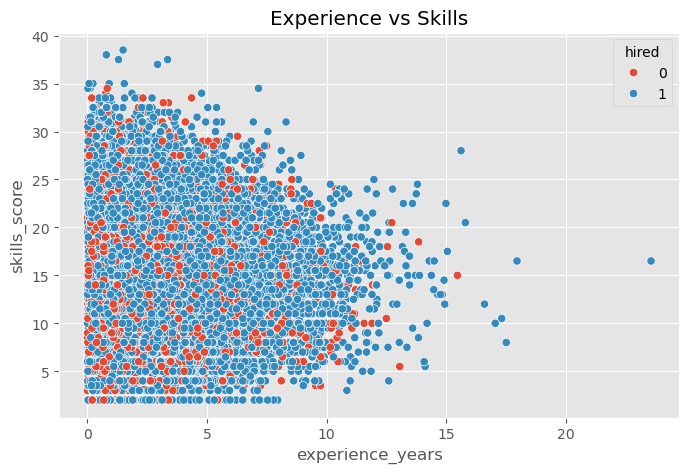

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="experience_years",
    y="skills_score",
    hue="hired"
)

plt.title("Experience vs Skills")

plt.show()

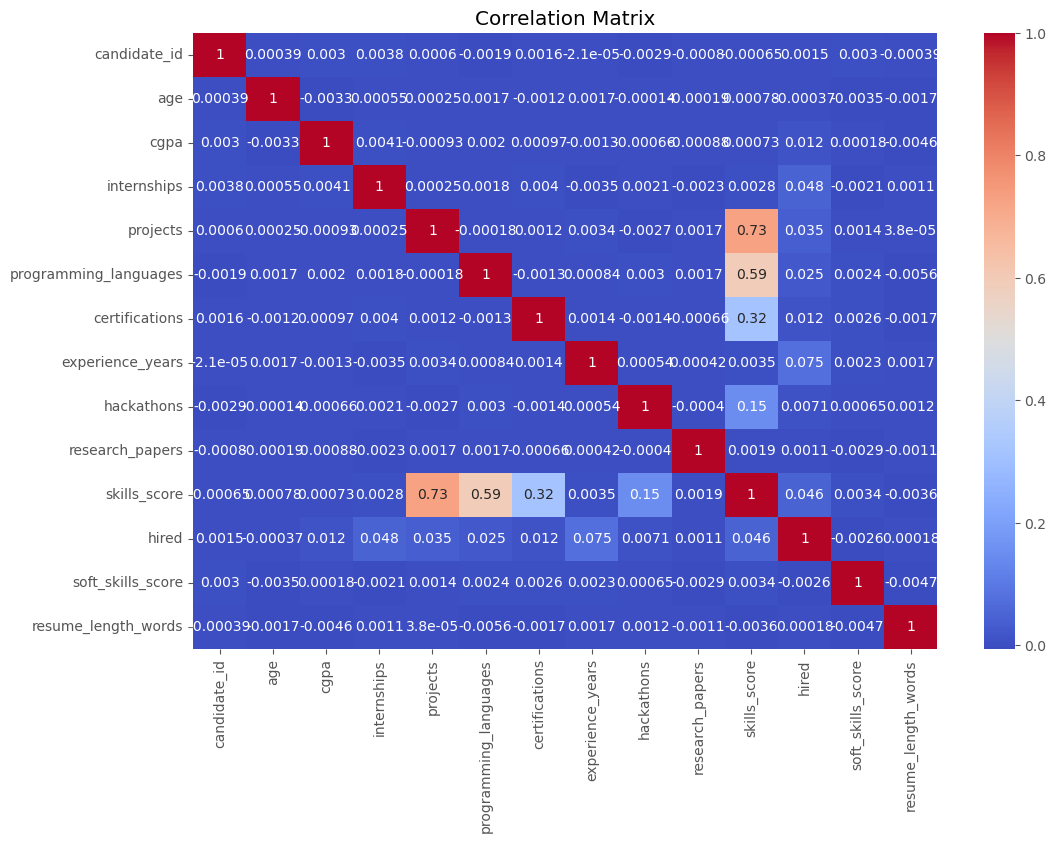

In [11]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [12]:
features = [
"age","cgpa","internships","projects",
"programming_languages","certifications",
"experience_years","hackathons",
"research_papers","skills_score",
"soft_skills_score","resume_length_words"
]

X = df[features]

y = df["hired"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [16]:
pred = model.predict(X_test)

In [17]:
print("Accuracy:", accuracy_score(y_test, pred))

print(classification_report(y_test, pred))

Accuracy: 0.703425
              precision    recall  f1-score   support

           0       0.38      0.02      0.04     11711
           1       0.71      0.99      0.82     28289

    accuracy                           0.70     40000
   macro avg       0.54      0.50      0.43     40000
weighted avg       0.61      0.70      0.59     40000



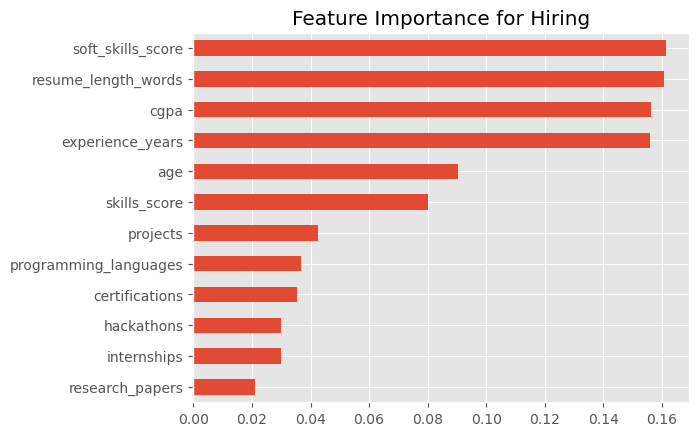

In [18]:
importance = pd.Series(
    model.feature_importances_,
    index=features
)

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance for Hiring")

plt.show()

In [19]:
print("Average Skills Score:", df["skills_score"].mean())

print("Average Experience:", df["experience_years"].mean())

Average Skills Score: 14.0008025
Average Experience: 1.4990299999999996
